# Cereal Nutrition Analysis and Rating Prediction

This notebook explores the nutritional content of 77 breakfast cereals and trains regression models to predict each cereal's rating from its nutrition facts.

**Questions**

1. How much sugar, fat, fibre and protein do popular cereals contain?
2. Which nutrients are associated with a higher or lower rating?
3. How well can linear models (Linear, Ridge, Lasso) predict the rating?

**Dataset:** [80 Cereals (Kaggle)](https://www.kaggle.com/datasets/crawford/80-cereals). Nutrition values are per serving.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

sns.set_theme(style="whitegrid")
Path("figures").mkdir(exist_ok=True)

## 1. Load the data

In [2]:
df = pd.read_csv("cereal.csv")
print(df.shape)
df.head()

(77, 16)


,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


| Column | Meaning |
| --- | --- |
| `mfr` | Manufacturer (see mapping below) |
| `type` | `C` = cold, `H` = hot |
| `calories`, `protein`, `fat`, `sodium`, `fiber`, `carbo`, `sugars`, `potass` | Per serving (kcal, g, g, mg, g, g, g, mg) |
| `vitamins` | % of daily vitamins and minerals (0, 25 or 100) |
| `shelf` | Display shelf in the store (1, 2 or 3, counted from the floor) |
| `weight`, `cups` | Weight in ounces and volume in cups of one serving |
| `rating` | Rating of the cereal (0-100) |

In [3]:
df.dtypes

name            str
mfr             str
type            str
calories      int64
protein       int64
fat           int64
sodium        int64
fiber       float64
carbo       float64
sugars        int64
potass        int64
vitamins      int64
shelf         int64
weight      float64
cups        float64
rating      float64
dtype: object

## 2. Data cleaning

There are no `NaN` values, but a few cells hold `-1`, which is impossible for a nutrient amount. These are missing values in disguise.

In [4]:
num_cols = df.select_dtypes("number").columns
print("NaN values:", df.isnull().sum().sum())
df[(df[num_cols] < 0).any(axis=1)][["name", "carbo", "sugars", "potass"]]

NaN values: 0


,name,carbo,sugars,potass
4,Almond Delight,14.0,8,-1
20,Cream of Wheat (Quick),21.0,0,-1
57,Quaker Oatmeal,-1.0,-1,110


Only 3 of 77 rows are affected. Imputing them would distort the relationship between nutrients and rating that we want to model, so they are dropped.

In [5]:
df = df[(df[num_cols] >= 0).all(axis=1)].reset_index(drop=True)

manufacturers = {
    "A": "American Home Food Products",
    "G": "General Mills",
    "K": "Kellogg's",
    "N": "Nabisco",
    "P": "Post",
    "Q": "Quaker Oats",
    "R": "Ralston Purina",
}
df["manufacturer"] = df["mfr"].map(manufacturers)
print(df.shape)
df.describe().round(2)

(74, 17)


,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
count,74.00,74.00,74.00,74.00,74.00,74.00,74.00,74.00,74.00,74.00,74.00,74.00,74.00
mean,107.03,2.51,1.00,162.36,2.18,14.73,7.11,98.51,29.05,2.22,1.03,0.82,42.37
std,19.84,1.08,1.01,82.77,2.42,3.89,4.36,70.88,22.29,0.83,0.15,0.24,14.03
min,50.00,1.00,0.00,0.00,0.00,5.00,0.00,15.00,0.00,1.00,0.50,0.25,18.04
25%,100.00,2.00,0.00,135.00,0.25,12.00,3.00,41.25,25.00,1.25,1.00,0.67,32.45
50%,110.00,2.50,1.00,180.00,2.00,14.50,7.00,90.00,25.00,2.00,1.00,0.75,40.25
75%,110.00,3.00,1.00,217.50,3.00,17.00,11.00,120.00,25.00,3.00,1.00,1.00,50.52
max,160.00,6.00,5.00,320.00,14.00,23.00,15.00,330.00,100.00,3.00,1.50,1.50,93.70


## 3. Exploratory analysis

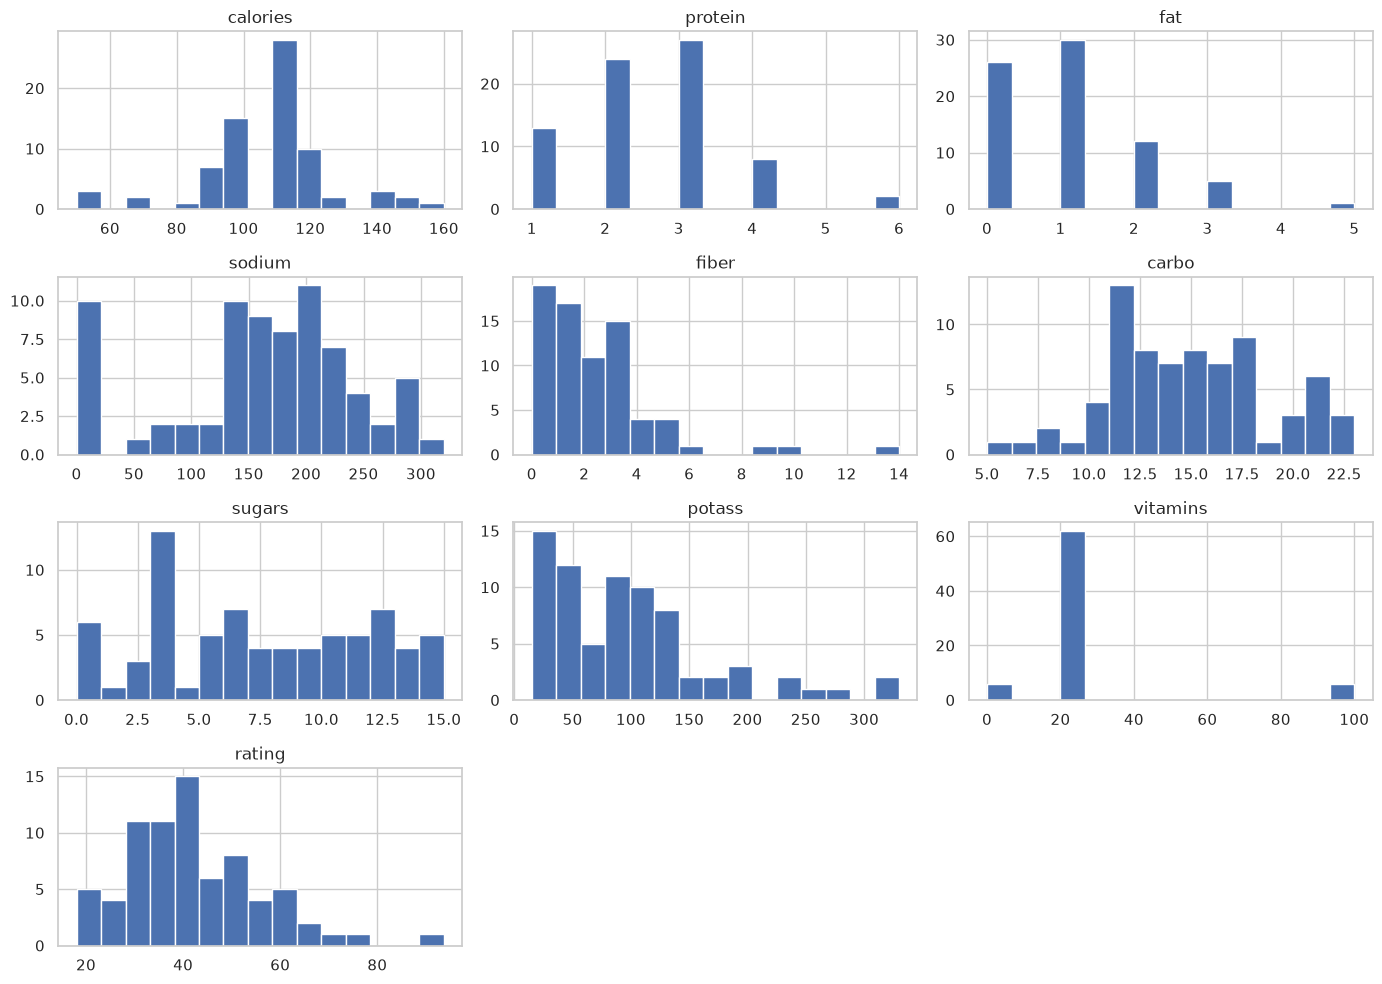

In [6]:
nutrients = ["calories", "protein", "fat", "sodium", "fiber", "carbo", "sugars", "potass", "vitamins"]
df[nutrients + ["rating"]].hist(figsize=(14, 10), bins=15, edgecolor="white")
plt.tight_layout()
plt.show()

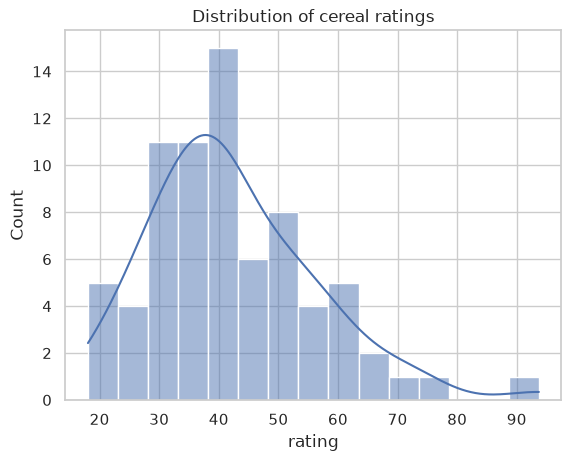

In [7]:
sns.histplot(df["rating"], kde=True, bins=15)
plt.title("Distribution of cereal ratings")
plt.show()

### How much sugar do cereals contain?

In [8]:
print(f"Median sugar per serving: {df['sugars'].median():.0f} g")
print(f"Cereals with 10 g or more sugar per serving: {(df['sugars'] >= 10).sum()} of {len(df)} ({(df['sugars'] >= 10).mean():.0%})")

# Share of each serving's weight that is sugar (1 oz = 28.35 g)
df["sugar_pct"] = df["sugars"] / (df["weight"] * 28.35) * 100
print(f"Median share of serving weight that is sugar: {df['sugar_pct'].median():.0f}%")

df.nlargest(10, "sugars")[["name", "manufacturer", "sugars", "sugar_pct", "rating"]].round(1)

Median sugar per serving: 7 g
Cereals with 10 g or more sugar per serving: 26 of 74 (35%)
Median share of serving weight that is sugar: 21%


,name,manufacturer,sugars,sugar_pct,rating
28,Golden Crisp,Post,15,52.9,35.3
63,Smacks,Kellogg's,15,52.9,31.2
5,Apple Jacks,Kellogg's,14,49.4,33.2
50,Post Nat. Raisin Bran,Post,14,37.1,37.8
67,Total Raisin Bran,General Mills,14,32.9,28.6
13,Cocoa Puffs,General Mills,13,45.9,22.7
17,Count Chocula,General Mills,13,45.9,22.4
22,Froot Loops,Kellogg's,13,45.9,32.2
44,Mueslix Crispy Blend,Kellogg's,13,30.6,30.3
9,Cap'n'Crunch,Quaker Oats,12,42.3,18.0


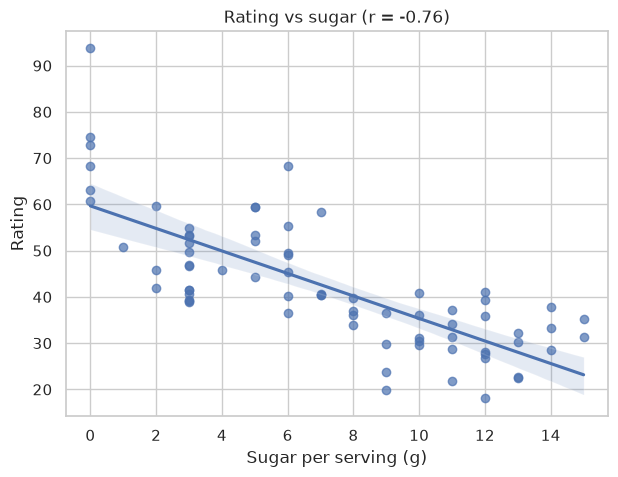

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=df, x="sugars", y="rating", ax=ax, scatter_kws={"alpha": 0.7})
ax.set(title=f"Rating vs sugar (r = {df['sugars'].corr(df['rating']):.2f})", xlabel="Sugar per serving (g)", ylabel="Rating")
fig.savefig("figures/rating_vs_sugar.png", dpi=120, bbox_inches="tight")
plt.show()

### Which nutrients move together with the rating?

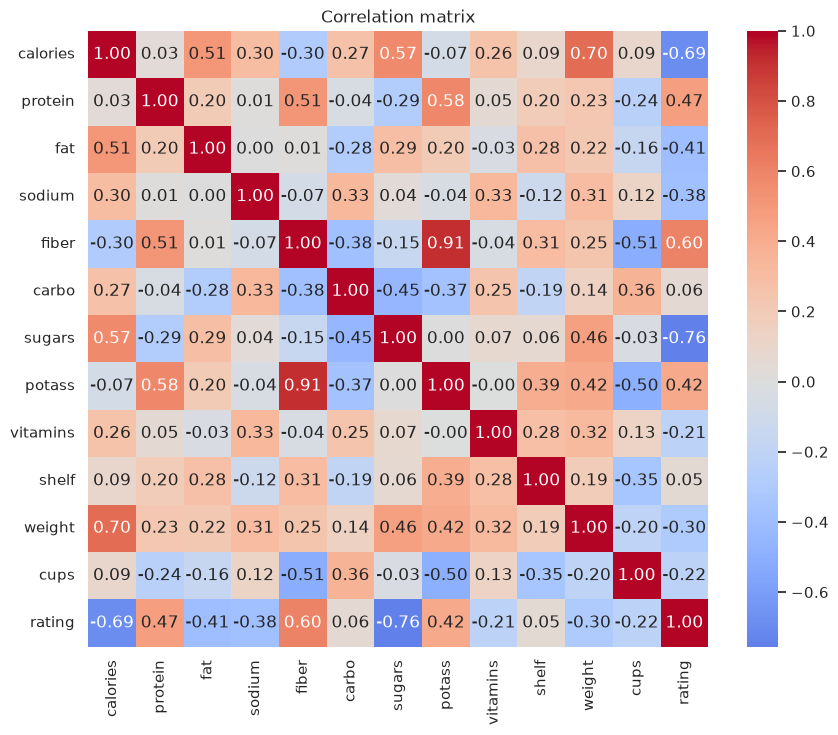

sugars     -0.755955
calories   -0.693785
fat        -0.405050
sodium     -0.383012
weight     -0.300461
cups       -0.222504
vitamins   -0.214481
shelf       0.051040
carbo       0.055941
potass      0.415782
protein     0.467162
fiber       0.603411
Name: rating, dtype: float64

In [10]:
corr = df[nutrients + ["shelf", "weight", "cups", "rating"]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix")
fig.savefig("figures/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

corr["rating"].drop("rating").sort_values()

Sugar, calories and fat have the strongest negative correlation with the rating, while fibre, protein and potassium have the strongest positive correlation.

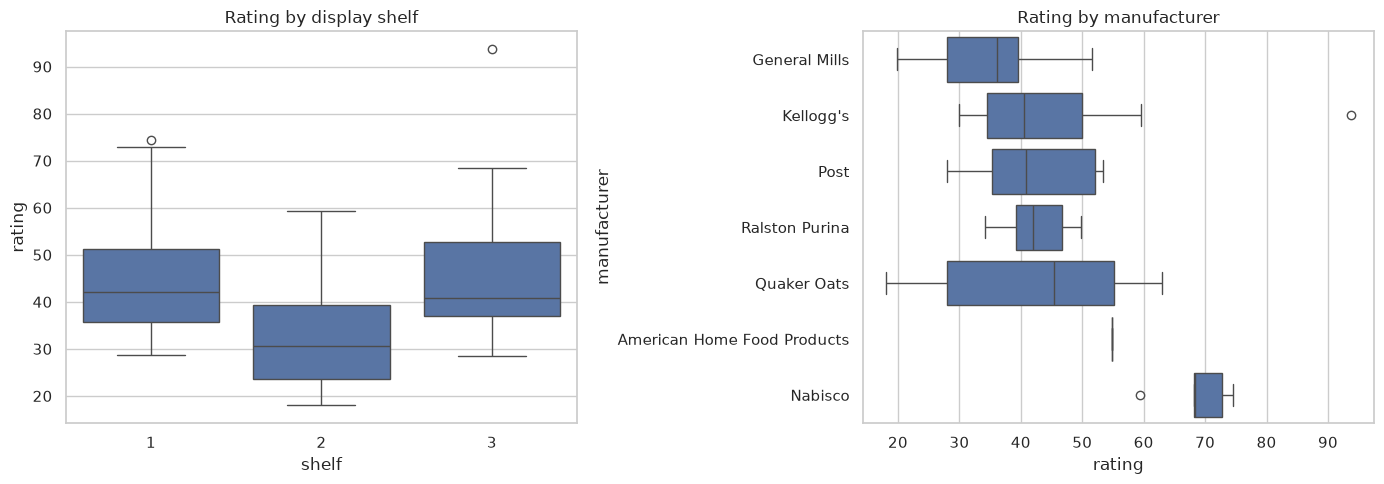

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="shelf", y="rating", ax=axes[0])
axes[0].set_title("Rating by display shelf")
order = df.groupby("manufacturer")["rating"].median().sort_values().index
sns.boxplot(data=df, y="manufacturer", x="rating", order=order, ax=axes[1])
axes[1].set_title("Rating by manufacturer")
plt.tight_layout()
plt.show()

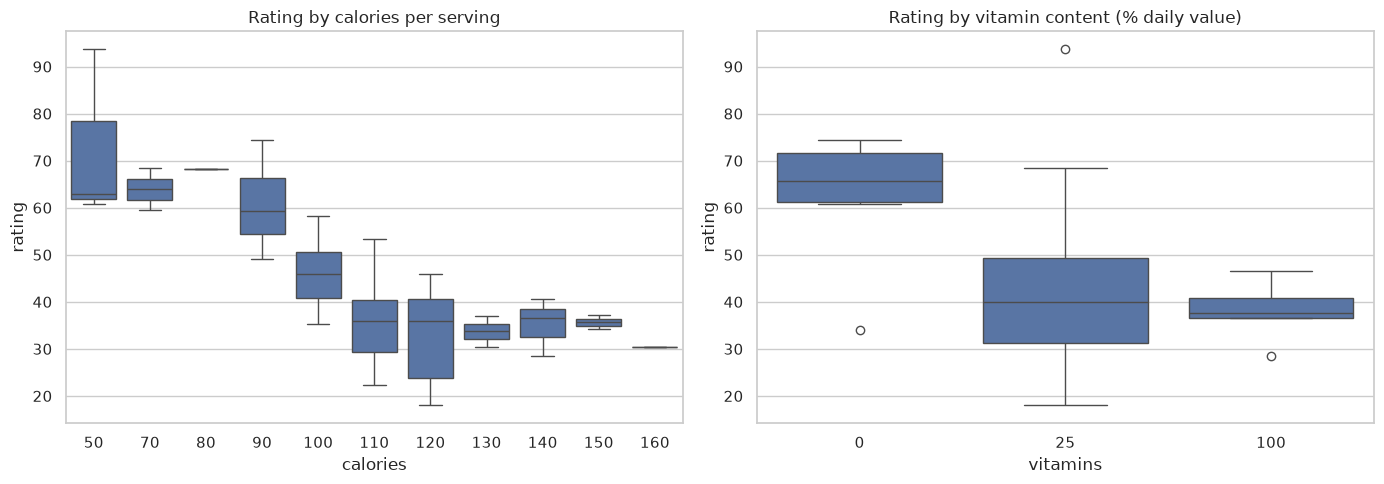

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="calories", y="rating", ax=axes[0])
axes[0].set_title("Rating by calories per serving")
sns.boxplot(data=df, x="vitamins", y="rating", ax=axes[1])
axes[1].set_title("Rating by vitamin content (% daily value)")
plt.tight_layout()
plt.show()

In [13]:
cols = ["name", "manufacturer", "sugars", "fiber", "protein", "rating"]
print("Highest rated")
display(df.nlargest(5, "rating")[cols].round(1))
print("Lowest rated")
display(df.nsmallest(5, "rating")[cols].round(1))

Highest rated


,name,manufacturer,sugars,fiber,protein,rating
3,All-Bran with Extra Fiber,Kellogg's,0,14.0,4,93.7
61,Shredded Wheat 'n'Bran,Nabisco,0,4.0,3,74.5
62,Shredded Wheat spoon size,Nabisco,0,3.0,3,72.8
0,100% Bran,Nabisco,6,10.0,4,68.4
60,Shredded Wheat,Nabisco,0,3.0,2,68.2


Lowest rated


,name,manufacturer,sugars,fiber,protein,rating
9,Cap'n'Crunch,Quaker Oats,12,0.0,1,18.0
11,Cinnamon Toast Crunch,General Mills,9,0.0,1,19.8
33,Honey Graham Ohs,Quaker Oats,11,1.0,1,21.9
17,Count Chocula,General Mills,13,0.0,1,22.4
13,Cocoa Puffs,General Mills,13,0.0,1,22.7


## 4. Predicting the rating

**Preprocessing**

- `mfr` and `type` are nominal categories, so they are one-hot encoded (label encoding would impose a fake order such as `K < N < P`).
- Numeric features are scaled to [0, 1] with `MinMaxScaler`.
- Both steps live inside a `Pipeline`, so the scaler is fitted on the training data only and no information leaks from the test set.

In [14]:
numeric = nutrients + ["shelf", "weight", "cups"]
categorical = ["mfr", "type"]
X = df[numeric + categorical]
y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print("Train:", X_train.shape, " Test:", X_test.shape)

preprocess = ColumnTransformer([
    ("num", MinMaxScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2, alpha=0.05)": Ridge(alpha=0.05),
    "Lasso (L1, alpha=0.001)": Lasso(alpha=0.001, max_iter=100_000),
}

Train: (51, 14)  Test: (23, 14)


In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)
results = []
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)]).fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append({
        "model": name,
        "test R2": r2_score(y_test, pred),
        "test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "test MAE": mean_absolute_error(y_test, pred),
        "5-fold CV R2": cross_val_score(pipe, X, y, cv=cv, scoring="r2").mean(),
    })

pd.DataFrame(results).set_index("model").round(4)

,test R2,test RMSE,test MAE,5-fold CV R2
model,,,,
Linear Regression,1.0000,0.0000,0.0000,1.0000
"Ridge (L2, alpha=0.05)",0.9941,0.9822,0.7864,0.9918
"Lasso (L1, alpha=0.001)",1.0000,0.0679,0.0553,1.0000


All three models explain essentially all of the variance. That is a strong hint that the rating is not an opinion score but a **formula computed from the nutrition facts**. We can check this by fitting a plain linear regression on the nine nutrient columns alone:

In [16]:
formula = LinearRegression().fit(df[nutrients], df["rating"])
print(f"R2 using only the 9 nutrients: {formula.score(df[nutrients], df['rating']):.6f}")

coef = pd.Series(formula.coef_, index=nutrients).sort_values()
print(f"Intercept: {formula.intercept_:.2f}")
coef.round(3).to_frame("rating points per unit")

R2 using only the 9 nutrients: 1.000000
Intercept: 54.93


,rating points per unit
fat,-1.691
sugars,-0.725
calories,-0.223
sodium,-0.054
vitamins,-0.051
potass,-0.034
carbo,1.092
protein,3.273
fiber,3.443


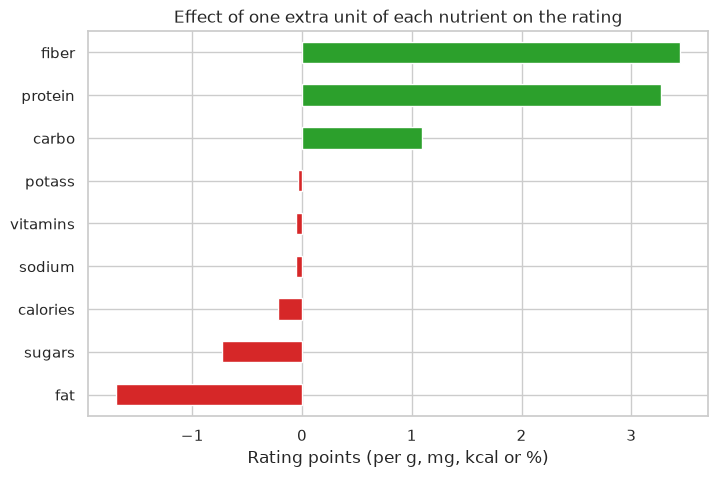

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
coef.plot.barh(color=np.where(coef > 0, "tab:green", "tab:red"), ax=ax)
ax.set(title="Effect of one extra unit of each nutrient on the rating", xlabel="Rating points (per g, mg, kcal or %)")
fig.savefig("figures/rating_coefficients.png", dpi=120, bbox_inches="tight")
plt.show()

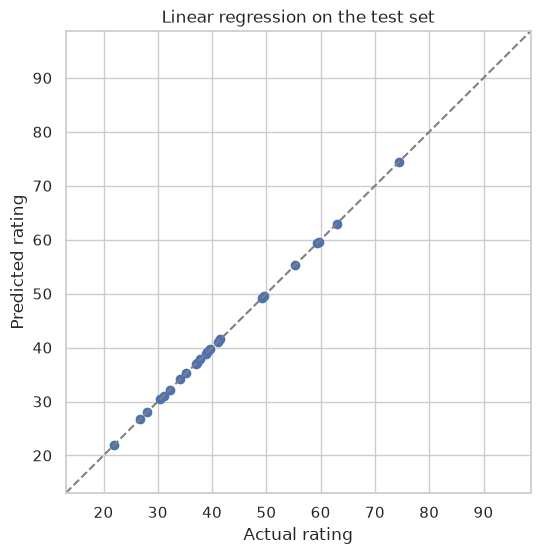

In [18]:
best = Pipeline([("preprocess", preprocess), ("model", LinearRegression())]).fit(X_train, y_train)
pred = best.predict(X_test)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred)
lims = [y.min() - 5, y.max() + 5]
ax.plot(lims, lims, "--", color="gray")
ax.set(xlim=lims, ylim=lims, xlabel="Actual rating", ylabel="Predicted rating", title="Linear regression on the test set")
plt.show()

## 5. Conclusions

- **Sugar is the biggest problem.** The median cereal contains 7 g of sugar per serving, about 21% of its weight, and 26 of the 74 cereals (35%) contain 10 g or more. Sugar has the strongest negative correlation with the rating (r = -0.76), and the ten most sugary cereals are all rated below 40.
- **The rating is an exact linear function of the nutrition facts.** A linear regression on nine nutrients reproduces it with R² = 1.0: every gram of fibre (+3.4) or protein (+3.3) raises it, while fat (-1.7), sugar (-0.7) and calories (-0.2 per kcal) lower it. Manufacturer, shelf position and serving size add no information.
- Because the relationship is exactly linear, regularisation brings no benefit here: Ridge slightly shrinks the true coefficients and scores marginally lower than ordinary least squares.